# 03 — Feature engineering cho dự báo PM2.5

Notebook kiểm tra bộ đặc trưng được tạo bởi `src/preprocessing/feature_engineering.py`. Mục tiêu là dự báo PM2.5 trước **1, 3 và 6 giờ** mà không làm rò rỉ dữ liệu tương lai.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'notebooks':
    ROOT = ROOT.parent
FEATURE_PATH = ROOT / 'data' / 'processed' / 'ml_features.csv.gz'
CLEAN_PATH = ROOT / 'data' / 'processed' / 'air_quality_clean.csv'
METADATA_PATH = ROOT / 'artifacts' / 'feature_metadata.json'
assert FEATURE_PATH.exists() and METADATA_PATH.exists()
metadata = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
metadata['report']

{'input_rows': 267976,
 'output_rows': 266584,
 'rows_removed': 1392,
 'stations': 8,
 'start': '2022-08-11T07:00:00+07:00',
 'end': '2026-05-30T17:00:00+07:00',
 'invalid_timestamps_removed': 0,
 'feature_count': 113,
 'target_count': 3,
 'missing_before_drop': {'pm25': 0,
  'pm10': 0,
  'co': 0,
  'no2': 0,
  'so2': 0,
  'o3': 0,
  'us_aqi': 192,
  'temperature': 0,
  'humidity': 0,
  'wind_speed': 0,
  'wind_direction': 0,
  'precipitation': 0,
  'rain': 0,
  'surface_pressure': 0,
  'cloud_cover': 0,
  'data_quality_score': 0,
  'is_possible_outlier': 0,
  'hour': 0,
  'day_of_week': 0,
  'day_of_month': 0,
  'day_of_year': 0,
  'week_of_year': 0,
  'month': 0,
  'quarter': 0,
  'is_weekend': 0,
  'hour_sin': 0,
  'hour_cos': 0,
  'dow_sin': 0,
  'dow_cos': 0,
  'month_sin': 0,
  'month_cos': 0,
  'pm25_lag_1h': 8,
  'pm25_lag_2h': 16,
  'pm25_lag_3h': 24,
  'pm25_lag_6h': 48,
  'pm25_lag_12h': 96,
  'pm25_lag_24h': 192,
  'pm25_lag_48h': 384,
  'pm25_lag_72h': 576,
  'pm25_lag_168

## 1. Danh mục feature

Các nhóm gồm giá trị hiện tại, lịch, biến chu kỳ, lag PM2.5, lag chất ô nhiễm/thời tiết, rolling, EWM và tương tác.

In [2]:
group_table = pd.DataFrame([
    {
        'Nhóm': group,
        'Số feature': len(columns),
        'Ví dụ': ', '.join(columns[:5]),
    }
    for group, columns in metadata['feature_groups'].items()
])
display(group_table)
display(pd.Series({
    'Tổng số feature': len(metadata['feature_columns']),
    'Số target': len(metadata['target_columns']),
    'Số dòng đầu ra': metadata['report']['output_rows'],
    'Giá trị ML còn thiếu': metadata['report']['remaining_missing_model_values'],
}).to_frame('Giá trị'))

,Nhóm,Số feature,Ví dụ
0,current,17,"pm25, pm10, co, no2, so2"
1,calendar,8,"hour, day_of_week, day_of_month, day_of_year, ..."
2,cyclical,6,"hour_sin, hour_cos, dow_sin, dow_cos, month_sin"
3,pm25_lags,9,"pm25_lag_1h, pm25_lag_2h, pm25_lag_3h, pm25_la..."
4,pollutant_lags,15,"pm10_lag_1h, pm10_lag_3h, pm10_lag_24h, co_lag..."
5,weather_lags,16,"temperature_lag_1h, temperature_lag_3h, temper..."
6,rolling,32,"pm25_rolling_mean_3h, pm25_rolling_std_3h, pm2..."
7,ewm,2,"pm25_ewm_halflife_6h, pm25_ewm_halflife_24h"
8,change_and_interaction,8,"pm25_change_1h, pm25_change_3h, pm25_trend_6h,..."


,Giá trị
Tổng số feature,113
Số target,3
Số dòng đầu ra,266584
Giá trị ML còn thiếu,0


## 2. Đọc một tập feature tiêu biểu

In [3]:
selected_features = [
    'pm25', 'pm10', 'humidity', 'wind_speed', 'precipitation',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_24h',
    'pm25_lag_168h', 'pm25_rolling_mean_3h', 'pm25_rolling_mean_24h',
    'pm25_rolling_std_24h', 'pm25_ewm_halflife_6h',
    'pm25_change_1h', 'pm25_trend_6h', 'wind_u', 'wind_v',
    'stagnation_proxy'
]
id_columns = ['timestamp', 'station_id', 'location_name']
usecols = id_columns + selected_features + metadata['target_columns']
features = pd.read_csv(FEATURE_PATH, usecols=usecols, low_memory=False)
features['timestamp'] = pd.to_datetime(features['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
display(features.head())
print(f'{len(features):,} dòng × {len(features.columns)} cột được đọc cho notebook.')

,timestamp,station_id,location_name,pm25,pm10,humidity,wind_speed,precipitation,hour_sin,hour_cos,...,pm25_rolling_std_24h,pm25_ewm_halflife_6h,pm25_change_1h,pm25_trend_6h,wind_u,wind_v,stagnation_proxy,target_pm25_t_plus_1h,target_pm25_t_plus_3h,target_pm25_t_plus_6h
0,2022-08-11 07:00:00+07:00,HN_BA_DINH,Ba Dinh,13.1,18.7,92.0,8.6,6.0,0.965926,-0.258819,...,7.591954,21.648392,2.0,-1.50,8.516305e+00,-1.196889,9.583333,15.0,20.5,28.3
1,2022-08-11 08:00:00+07:00,HN_BA_DINH,Ba Dinh,15.0,21.4,92.0,5.2,4.3,0.866025,-0.500000,...,7.588473,20.715752,1.9,-0.44,5.196832e+00,0.181477,14.838710,16.3,26.7,29.2
2,2022-08-11 09:00:00+07:00,HN_BA_DINH,Ba Dinh,16.3,23.3,92.0,2.7,3.0,0.707107,-0.707107,...,7.658107,20.092155,1.3,0.42,1.624901e+00,2.156316,24.864864,20.5,28.5,26.9
3,2022-08-11 10:00:00+07:00,HN_BA_DINH,Ba Dinh,20.5,29.2,88.0,5.4,1.2,0.500000,-0.866025,...,7.716639,19.678427,4.2,0.90,-6.613093e-16,5.400000,13.750000,26.7,28.3,26.1
4,2022-08-11 11:00:00+07:00,HN_BA_DINH,Ba Dinh,26.7,38.2,90.0,7.7,1.0,0.258819,-0.965926,...,7.642806,19.768060,6.2,1.84,-9.429781e-16,7.700000,10.344828,28.5,29.2,23.9


266,584 dòng × 31 cột được đọc cho notebook.


## 3. Kiểm tra leakage bằng dữ liệu gốc

Tại thời điểm `t`, `pm25_lag_1h` phải bằng PM2.5 ở `t-1`; rolling mean 24 giờ phải bằng trung bình `[t-24, …, t-1]`, không chứa giá trị tại `t`.

In [4]:
clean = pd.read_csv(
    CLEAN_PATH, usecols=['timestamp', 'station_id', 'pm25'], low_memory=False
)
clean['timestamp'] = pd.to_datetime(clean['timestamp'], utc=True).dt.tz_convert('Asia/Ho_Chi_Minh')
station = features['station_id'].iloc[0]
feature_row = features.loc[features['station_id'].eq(station)].iloc[500]
station_clean = clean.loc[clean['station_id'].eq(station)].set_index('timestamp').sort_index()
t = feature_row['timestamp']
expected_lag_1h = station_clean.loc[t - pd.Timedelta(hours=1), 'pm25']
expected_roll_24h = station_clean.loc[
    t - pd.Timedelta(hours=24):t - pd.Timedelta(hours=1), 'pm25'
].mean()
assert np.isclose(feature_row['pm25_lag_1h'], expected_lag_1h)
assert np.isclose(feature_row['pm25_rolling_mean_24h'], expected_roll_24h)
display(pd.DataFrame({
    'Kiểm tra': ['lag 1 giờ', 'rolling mean 24 giờ'],
    'Feature': [feature_row['pm25_lag_1h'], feature_row['pm25_rolling_mean_24h']],
    'Tính trực tiếp từ quá khứ': [expected_lag_1h, expected_roll_24h],
    'Đạt': [True, True],
}))

,Kiểm tra,Feature,Tính trực tiếp từ quá khứ,Đạt
0,lag 1 giờ,49.200,49.200,True
1,rolling mean 24 giờ,42.475,42.475,True


## 4. Quan hệ giữa feature và target

,Spearman với target_pm25_t_plus_3h
pm25,0.843
pm10,0.792
pm25_lag_1h,0.770
pm25_rolling_mean_3h,0.712
pm25_ewm_halflife_6h,0.653
pm25_rolling_mean_24h,0.637
pm25_lag_3h,0.635
pm25_lag_6h,0.488
pm25_lag_24h,0.481
pm25_rolling_std_24h,0.473


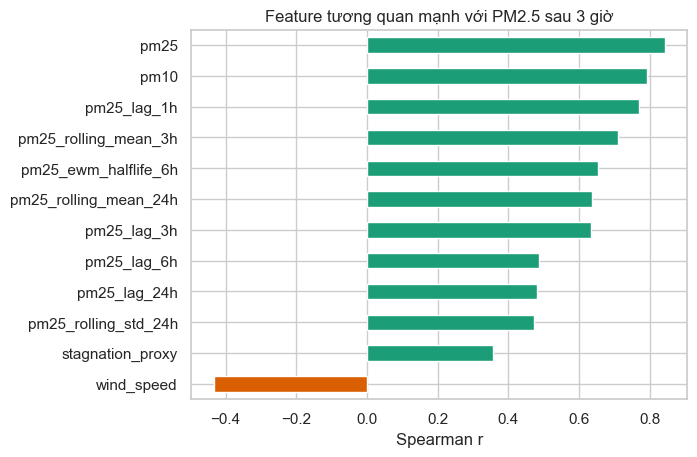

In [5]:
target = 'target_pm25_t_plus_3h'
numeric = features[selected_features + [target]]
correlations = numeric.corr(method='spearman')[target].drop(target).sort_values(
    key=lambda values: values.abs(), ascending=False
)
display(correlations.head(15).round(3).to_frame(f'Spearman với {target}'))

top = correlations.head(12).sort_values()
ax = top.plot.barh(color=np.where(top > 0, '#1b9e77', '#d95f02'))
ax.set(title='Feature tương quan mạnh với PM2.5 sau 3 giờ', xlabel='Spearman r', ylabel='')
plt.show()

## 5. Trực quan lag và rolling feature

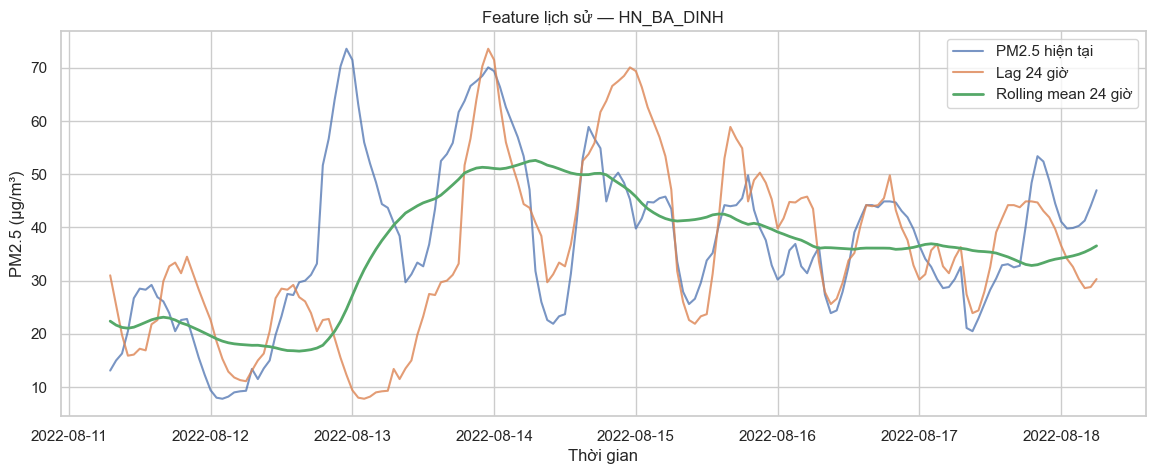

In [6]:
example = features.loc[features['station_id'].eq(station)].iloc[:24 * 7]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(example['timestamp'], example['pm25'], label='PM2.5 hiện tại', alpha=.75)
ax.plot(example['timestamp'], example['pm25_lag_24h'], label='Lag 24 giờ', alpha=.8)
ax.plot(example['timestamp'], example['pm25_rolling_mean_24h'], label='Rolling mean 24 giờ', linewidth=2)
ax.set(title=f'Feature lịch sử — {station}', xlabel='Thời gian', ylabel='PM2.5 (µg/m³)')
ax.legend()
plt.show()

## 6. Kết luận

- Bảng ML có 113 feature và target PM2.5 cho 1, 3, 6 giờ tới.
- Lag dài nhất là 168 giờ, giúp mô hình học chu kỳ tuần.
- Rolling/EWM chỉ dùng `t-1` trở về trước.
- Đặc trưng thời gian được mã hóa cả dạng số và sin/cos để giữ tính tuần hoàn.
- Vector gió, tỷ lệ PM2.5/PM10, biến trì trệ và tương tác độ ẩm–nhiệt độ bổ sung thông tin vật lý.
- Việc chia train/validation/test phải thực hiện theo thời gian trong notebook forecasting tiếp theo, tuyệt đối không random split.